# Laurentia A and B paleomagnetic poles (1800 to 700 Ma)

This notebook is a simplified version of a notebook developed associated with a compilation of Laurentia paleomagnetic poles that was developed in:

> Evans, D.A.D, Pesonen, L.J., Eglington, B.M., Elming, S.-Å., Gong, Z., Li, Z.-X., McCausland, P.J., Meert, J.G., Mertanen, S., Pisarevsky, S.A., Pivarunas, A.F., Salminen, J.M., Swanson-Hysell, N.L., Torsvik, T.H., Trindade, R.I.F., Veikkolainen, T., and Zhang, S. (2021), An expanding list of reliable paleomagnetic poles for Precambrian tectonic reconstructions, in: Pesonen, L.J., Salminen, J., Evans, D.A.D., Elming, S.-Å., Veikkolainen, T. (eds.) Ancient Supercontinents and the Paleogeography of the Earth.

and plotted and analyzed in:

> Swanson-Hysell, N.L. (2021), The Precambrian Paleogeography of Laurentia, in: Pesonen, L.J., Salminen, J., Evans, D.A.D., Elming, S.-Å., Veikkolainen, T. (eds.) Ancient Supercontinents and the Paleogeography of the Earth, doi:10.1016/B978-0-12-818533-9.00009-6.
| [open access version](https://escholarship.org/uc/item/9ft608qj) |

It loads a compilation of paleomagnetic poles for Laurentia and then plots the poles given "A" and "B" grades in the Evans et al. (2021) compilation. Poles for both Laurentia and Greenland (rotated back to Laurentia) from 1800 and 700 Ma are what are filtered for and plotted.

In [2]:
!pip install pmagpy
!pip install cartopy

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag

## Load the pole compilation

We are going to go access data published in this file:
https://github.com/Swanson-Hysell-Group/Laurentia_Paleogeography/raw/refs/heads/master/Data/Leirubakki_Laurentia.xlsx

Each row is one published pole. Important columns:

- `Terrane` — the block the pole belongs to (e.g. `Laurentia`, `Laurentia-Greenland`)
- `ROCKNAME` — the rock unit name
- `PLAT`, `PLONG` — pole latitude and longitude (in the local block's coordinates)
- `A95` — radius of the 95% confidence circle on the pole
- `Grade` — Nordic Paleogeography working-group rating: `A`, `B`, or `NR`
- `nominal age`, `lomagage`, `himagage` — preferred age and age bounds in Ma

In [15]:
poles = pd.read_excel('https://github.com/Swanson-Hysell-Group/Laurentia_Paleogeography/raw/refs/heads/master/Data/Leirubakki_Laurentia.xlsx')
print(f'{len(poles)} poles in the full compilation')
poles[['Terrane', 'ROCKNAME', 'Grade', 'nominal age', 'PLAT', 'PLONG', 'A95']].head()

107 poles in the full compilation


,Terrane,ROCKNAME,Grade,nominal age,PLAT,PLONG,A95
0,Laurentia-Wyoming,Stillwater Complex - C2,A,2705.0,-83.6,335.8,4.042307
1,Laurentia-Superior(East),Otto Stock dikes and aureole,B,2676.0,69.0,227.0,4.837355
2,Laurentia-Slave,Defeat Suite,B,2625.0,-1.0,64.0,15.000000
3,Laurentia-Superior(East),Ptarmigan-Mistassini dikes,B,2505.0,-45.3,213.0,13.800000
4,Laurentia-Superior(East),Matachewan dikes R,A,2466.0,-44.1,238.3,1.600000


## Filter to A and B poles between 1800 and 700 Ma

We drop `NR` (not rated) poles and exclude poles from the Scotland and Svalbard terranes. Greenland poles are kept and will be rotated to Laurentia coordinates in the next step.

In [16]:
excluded_terranes = ['Laurentia-Scotland', 'Laurentia-Svalbard', 'Laurentia-Trans-Hudson orogen']

poles_filtered = poles[
    poles['Grade'].isin(['A', 'B'])
    & poles['nominal age'].between(700, 1800)
    & ~poles['Terrane'].isin(excluded_terranes)
].copy()

print(f'{len(poles_filtered)} poles after filtering')
print()
print('Counts by terrane and grade:')
print(poles_filtered.groupby(['Terrane', 'Grade']).size())

52 poles after filtering

Counts by terrane and grade:
Terrane              Grade
Laurentia            A        27
                     B        12
Laurentia-Greenland  A         1
                     B        12
dtype: int64


## Rotate Greenland poles to Laurentia coordinates

Greenland separated from Laurentia in the Cenozoic during the opening of Baffin Bay and the Labrador Sea. To compare Greenland poles to Laurentian poles for the Precambrian time interval here, we rotate them back into Laurentia coordinates using the Euler pole of [Roest & Srivastava (1989)](https://doi.org/10.1130/0091-7613(1989)017%3C1000:SOLAGT%3E2.3.CO;2):

- Euler pole: 67.5°N, 118.5°W
- rotation angle: −13.8° (counterclockwise as viewed looking down on the Euler pole)

The `pmag.pt_rot` function takes the Euler pole as `[lat, lon, angle]` and a list of latitudes and longitudes to rotate. We add new columns `Laurentia_plat` and `Laurentia_plon` so the original (block-local) coordinates are preserved.

In [17]:
Greenland_Euler = [67.5, -118.5, -13.8]  # [lat, lon, CCW angle]

poles_filtered['Laurentia_plat'] = poles_filtered['PLAT']
poles_filtered['Laurentia_plon'] = poles_filtered['PLONG']

is_greenland = poles_filtered['Terrane'].isin(
    ['Laurentia-Greenland']
)

for idx in poles_filtered[is_greenland].index:
    plat, plon = pmag.pt_rot(
        Greenland_Euler,
        [poles_filtered.loc[idx, 'PLAT']],
        [poles_filtered.loc[idx, 'PLONG']],
    )
    poles_filtered.loc[idx, 'Laurentia_plat'] = plat[0]
    poles_filtered.loc[idx, 'Laurentia_plon'] = plon[0]

Sort by age (oldest first) and split the table into Laurentia (autochthonous) and Greenland (rotated) subsets for plotting.

In [18]:
poles_filtered = poles_filtered.sort_values('nominal age', ascending=False).reset_index(drop=True)

is_greenland = poles_filtered['Terrane'].isin(['Laurentia-Greenland', 'Laurentia-Greenland-Nain'])
laurentia_poles = poles_filtered[~is_greenland].copy()
greenland_poles = poles_filtered[is_greenland].copy()

print(f'{len(laurentia_poles)} Laurentia poles, {len(greenland_poles)} Greenland poles (rotated)')
poles_filtered[['Terrane', 'ROCKNAME', 'Grade', 'nominal age', 'PLAT', 'PLONG', 'Laurentia_plat', 'Laurentia_plon', 'A95']]

39 Laurentia poles, 13 Greenland poles (rotated)


,Terrane,ROCKNAME,Grade,nominal age,PLAT,PLONG,Laurentia_plat,Laurentia_plon,A95
0,Laurentia,Dubawnt Group,B,1785.0,7.000000,277.000000,7.000000,277.000000,8.000000
1,Laurentia,Cleaver dikes,A,1740.5,19.400000,276.700012,19.400000,276.700012,6.100000
2,Laurentia-Greenland,Melville Bugt diabase dikes,B,1633.0,5.000000,273.800000,2.681808,261.359472,8.700000
3,Laurentia,Western Channel Diabase,A,1590.0,9.000000,245.000000,9.000000,245.000000,6.622688
4,Laurentia,St.Francois Mountains Acidic Rocks,A,1476.0,-13.200000,219.000000,-13.200000,219.000000,6.131884
5,Laurentia,Michikamau Intrusion,A,1460.0,-1.500000,217.500000,-1.500000,217.500000,4.666905
6,Laurentia,Spokane Formation,A,1457.5,-24.799999,215.500000,-24.799999,215.500000,4.700000
7,Laurentia,Snowslip Formation,A,1449.5,-24.900000,210.199997,-24.900000,210.199997,3.500000
8,Laurentia,Tobacco Root dikes,B,1448.0,8.700000,216.100000,8.700000,216.100000,10.483358
9,Laurentia,Purcell Lava,A,1443.0,-23.600000,215.600006,-23.600000,215.600006,4.800000


In [19]:
laur_A = laurentia_poles[laurentia_poles['Grade'] == 'A']
laur_B = laurentia_poles[laurentia_poles['Grade'] == 'B']
green_A = greenland_poles[greenland_poles['Grade'] == 'A']
green_B = greenland_poles[greenland_poles['Grade'] == 'B']

def plot_pole_compilation(map_axis):
    ipmag.plot_poles_colorbar(
    map_axis,
    laur_A['Laurentia_plon'].tolist(), laur_A['Laurentia_plat'].tolist(),
    laur_A['A95'].tolist(), laur_A['nominal age'].tolist(),
    age_min, age_max, marker='o', colormap=colormap, colorbar=True,
    )
    ipmag.plot_poles_colorbar(
        map_axis,
        laur_B['Laurentia_plon'].tolist(), laur_B['Laurentia_plat'].tolist(),
        laur_B['A95'].tolist(), laur_B['nominal age'].tolist(),
        age_min, age_max, marker='s', colormap=colormap, colorbar=False,
    )
    ipmag.plot_poles_colorbar(
        map_axis,
        green_A['Laurentia_plon'].tolist(), green_A['Laurentia_plat'].tolist(),
        green_A['A95'].tolist(), green_A['nominal age'].tolist(),
        age_min, age_max, marker='p', colormap=colormap, colorbar=False,
    )
    ipmag.plot_poles_colorbar(
        map_axis,
        green_B['Laurentia_plon'].tolist(), green_B['Laurentia_plat'].tolist(),
        green_B['A95'].tolist(), green_B['nominal age'].tolist(),
        age_min, age_max, marker='P', colormap=colormap, colorbar=False,
    )

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Laurentia A', markerfacecolor='k', markersize=9),
        Line2D([0], [0], marker='s', color='w', label='Laurentia B', markerfacecolor='k', markersize=9),
        Line2D([0], [0], marker='p', color='w', label='Greenland A (rotated)', markerfacecolor='k', markersize=10),
        Line2D([0], [0], marker='P', color='w', label='Greenland B (rotated)', markerfacecolor='k', markersize=10),
    ]
    plt.legend(handles=legend_elements, loc='lower left', fancybox=True, fontsize=11)

        

## Plot the apparent polar wander path

Each pole is plotted with its A95 confidence circle and is colored by its nominal age. Marker shape encodes whether the pole is from the autochthonous Laurentian craton (circle/square for grade A/B) or from rotated Greenland (pentagon for A, plus-filled for B).

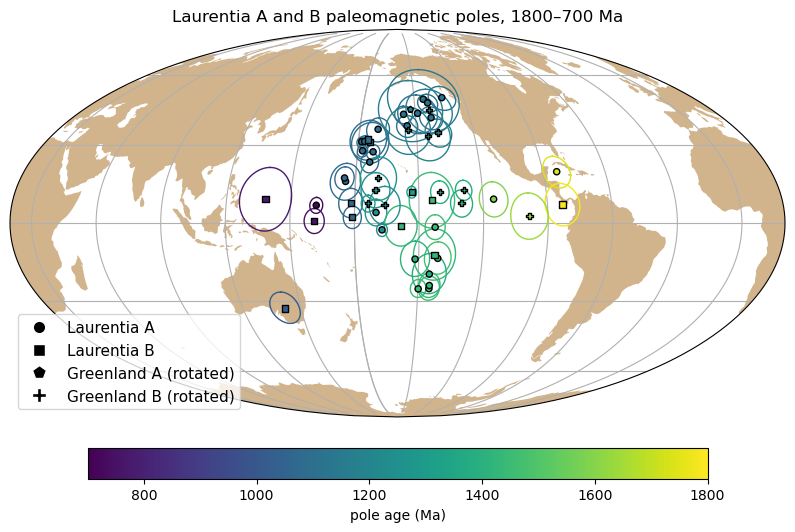

In [20]:
age_min, age_max = 700, 1800
colormap = 'viridis'

map_axis = ipmag.make_mollweide_map(central_longitude=200, figsize=(10, 8), land_edge_color='none')

plot_pole_compilation(map_axis)

plt.title('Laurentia A and B paleomagnetic poles, 1800–700 Ma')
plt.show()

We can also plot them on a globe that is a view from space (i.e. an orthographic map).

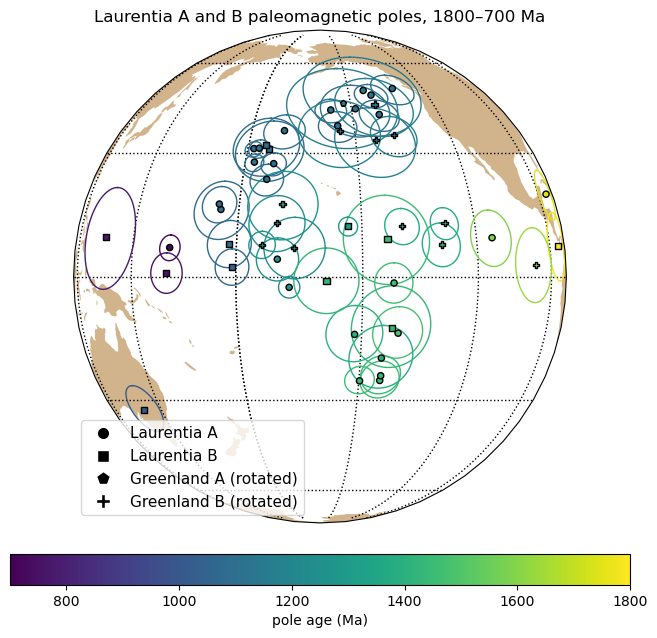

In [21]:
age_min, age_max = 700, 1800
colormap = 'viridis'

map_axis = ipmag.make_orthographic_map(central_longitude=200, figsize=(10, 8), land_edge_color='none')

plot_pole_compilation(map_axis)

plt.title('Laurentia A and B paleomagnetic poles, 1800–700 Ma')
plt.show()

## Notes for your final project

The colorbar maps pole age to color, so the trajectory of the apparent polar wander path can be read by following the color gradient from older (one end of the colormap) to younger (the other).

You can plot a single pole on top of this pole compilation. Let's do that below for the East Central MN Batholith pole which is `pole longitude: 265.8°; pole latitude: 20.4°; A95: 4.5°; K: 45.6 N: 23`

In [22]:
ECMB_pole_lon = 265.8
ECMB_pole_lat = 20.4
ECMB_A95 = 4.5

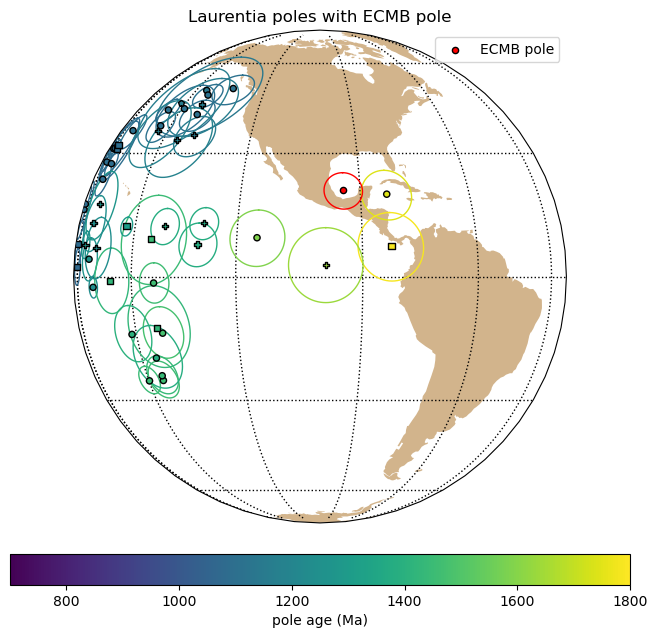

In [23]:
age_min, age_max = 700, 1800
colormap = 'viridis'

map_axis = ipmag.make_orthographic_map(central_longitude=260, 
                                       figsize=(10, 8), land_edge_color='none')

plot_pole_compilation(map_axis)

ipmag.plot_pole(map_axis, ECMB_pole_lon, ECMB_pole_lat, 
                ECMB_A95, color='red', label='ECMB pole')

plt.legend()

plt.title('Laurentia poles with ECMB pole')
plt.show()

## Make a Phanerozoic poles plot

Bringing in the Laurentia poles compilation from Torsvik et al., 2012.

In [ ]:
Phan_poles = pd.read_csv('https://github.com/Swanson-Hysell-Group/Laurentia_Paleogeography/raw/refs/heads/master/Data/Torsvik_Laurentia_Pole_Compilation.csv')
Phan_poles['North_pole_lat'] = Phan_poles['PLAT']
Phan_poles.tail()

,Q,A95,Com,Formation,Lat,Lon,CLat,CLon,RLat,RLon,EULER,Age,GPDB RefNo/Reference
178,5,7.1,NaN,Taum Sauk limestone,3.4,355.1,3.4,355.1,NaN,NaN,NaN,500.0,"1284, T96"
179,6,4.3,NaN,Royer Dolomite,-12.6,337.3,-12.6,337.3,NaN,NaN,NaN,500.0,"2289, T96"
180,6,10.0,NaN,Florida Mountains,5.4,348.7,5.4,348.7,NaN,NaN,NaN,503.0,"2375, T96"
181,5,3.3,NaN,Tapeats Sandstone,-0.6,341.1,-1.7,342.6,NaN,NaN,NaN,508.0,"1044, T96"
182,5,6.2,NaN,Mont Rigaud and Chatham_Grenville,11.9,4.5,11.9,4.5,NaN,NaN,NaN,532.0,"McCausland et al., 2007"


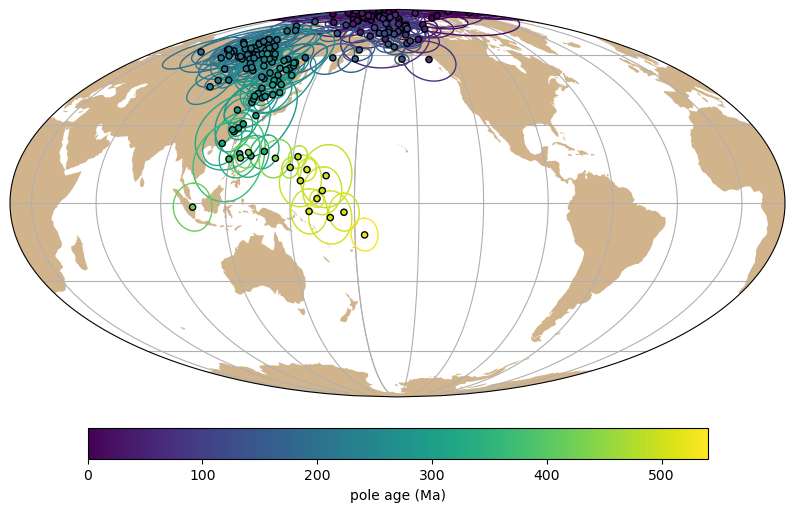

In [28]:
age_min, age_max = 0, 540
colormap = 'viridis'

map_axis = ipmag.make_mollweide_map(central_longitude=200, figsize=(10, 8), land_edge_color='none')

ipmag.plot_poles_colorbar(
map_axis,
Phan_poles['CLon']+180, -Phan_poles['CLat'],
Phan_poles['A95'], Phan_poles['Age'],
age_min, age_max, marker='o', colormap=colormap, colorbar=True,
)

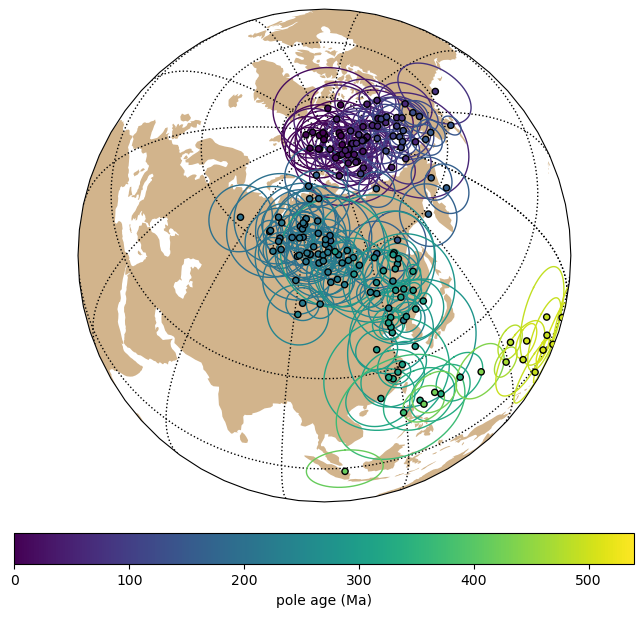

In [32]:
age_min, age_max = 0, 540
colormap = 'viridis'

map_axis = ipmag.make_orthographic_map(central_longitude=100, central_latitude=60, figsize=(10, 8), land_edge_color='none')

ipmag.plot_poles_colorbar(
map_axis,
Phan_poles['CLon']+180, -Phan_poles['CLat'],
Phan_poles['A95'], Phan_poles['Age'],
age_min, age_max, marker='o', colormap=colormap, colorbar=True,
)